# Inverse UQ example: Shocktube

In [190]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import umbridge as um
from matplotlib.animation import FuncAnimation
from Riemann import RiemannProblem

from scipy.integrate import solve_ivp

import tinyDA as tda

In [191]:
np.random.seed(42)

We implement two slightly incompatible models. `UmbridgeArepoModel` obeys the UM-Bridge interface, and `NpArepoModel` is a wrapper that is compatible with tinyDA.

In [211]:
class UmbridgeArepoModel(um.Model):
    def __init__(self):
        super().__init__("forward")

    def get_input_sizes(self, config):
        return [4]
    
    def get_output_sizes(self, config):
        return [4]
    
    def __call__(self, parameters, config={}):
        RESOLUTION = 200
        input = parameters[0]
        rho_L, v_L, p_L = input[0]
        rho_R, v_R, p_R = input[1]
        T_max, n_T = input[2]
        L_max, n_L = input[3]

        time = np.linspace(0, T_max, n_T + 1)
        solutions = [
            RiemannProblem(np.linspace(0, L_max, RESOLUTION), L_max / 2.0, [p_L, v_L, rho_L], [p_R, v_R, rho_R], 1.4, t)[1]
            for t in time
        ]

        def convert_space_index(input):
            return int(input * (RESOLUTION - 1) / n_L)

        return [
            [
                [], # x coordinates
                [
                    [
                        solutions[t][convert_space_index(s), 0] # 0 = density
                        for s in range(n_L + 1)
                    ]
                    for t in range(len(time))
                ],
                [
                    [
                        solutions[t][convert_space_index(s), 1] # 1 = velocity
                        for s in range(n_L + 1)
                    ]
                    for t in range(len(time))
                ],
                [
                    [
                        solutions[t][convert_space_index(s), 2] # 2 = pressure
                        for s in range(n_L + 1)
                    ]
                    for t in range(len(time))
                ]
            ]
        ]

    def supports_evaluate(self):
        return True
    
class NpArepoModel(um.Model):
    def __init__(self, inner_model, n_L=5, n_T=20, L_max=20, T_max=20, verbose=False):
        self.inner = inner_model
        self.n_L = n_L
        self.n_T = n_T
        self.L_max = L_max
        self.T_max = T_max
        self.verbose = verbose

    def __call__(self, parameters):
        left = [0, 0, 0]
        right = [0, 0, 0]
        left[0] = parameters[0]
        left[1] = 0.0
        left[2] = parameters[1]
        right[0] = parameters[2]
        right[1] = 0.0
        right[2] = parameters[3]
        inner_args = [[left, right, [self.T_max, self.n_T], [self.L_max, self.n_L]]]
        if self.verbose:
            print("Inner input:")
            print(inner_args)
        inner_result = self.inner(inner_args)[0][3]
        if self.verbose:
            print("Inner output:")
            print(inner_result)
        return np.array(inner_result).flatten(), True

# Visualize the exact model

In [214]:
# test_model = UmbridgeArepoModel()

# # Set up the figure and axis
# fig, ax = plt.subplots(figsize=(10, 6))
# line, = ax.plot([], [], 'b-')
# ax.set_xlim(0, 20)
# ax.set_ylim(0, 1.1)  # Adjust as needed
# ax.set_title('Pressure Distribution in Riemann Problem')
# ax.set_xlabel('Position')
# ax.set_ylabel('Pressure')
# ax.grid(True)

# L_max = T_max = 20
# n_L = 50
# n_T = 20

# results = test_model([[[1.0, 0.0, 1.0], [0.125, 0.0, 0.1], [T_max, n_T], [L_max, n_L]]])[0]

# # Animation update function
# def update(frame):
#     t = frame
#     pressure = results[1][t]
#     print(pressure)
#     line.set_data(np.linspace(0, L_max, n_L + 1), pressure)
#     ax.set_title(f'Pressure Distribution in Riemann Problem (t = {t:.3f})')
#     return line,

# # Create the animation
# anim = FuncAnimation(fig, update, frames=21, interval=50, blit=True)

# # Display the animation
# from IPython.display import HTML
# HTML(anim.to_jshtml())

### Set up the exact and numerical model

In [213]:
# set the true parameters. Our (noisy) measurements are based on these.
rho_L = 1.0 # initial density of the left half
p_L = 1.0 # initial pressure of the left half
rho_R = 0.125 # initial density of the right half
p_R = 0.1 # initial pressure of the right half
T_max = 20
n_T = 5
L_max = 20
n_L = 5

# collect the parameters in a vector. 
# we sample the log of the parameters and take the exponential
# inside the model to keep the parameters positive.
true_parameters = np.array([rho_L, p_L, rho_R, p_R])

my_exact_model = NpArepoModel(UmbridgeArepoModel(), n_L=n_L, n_T=n_T, L_max=L_max, T_max=T_max)

# initalise the true model and solve it
# http_model = um.HttpModel("http://localhost:4242", "forward")
# my_model = NpArepoModel(http_model, n_L=n_L, n_T=n_T, L_max=L_max, T_max=T_max, verbose=False)
my_model = NpArepoModel(UmbridgeArepoModel(), n_L=n_L, n_T=n_T, L_max=L_max, T_max=T_max, verbose=False)
y_true = my_model(true_parameters)[0]

### Generate data

In [196]:
# set the noise level
sigma = 1.0

experimental_measurements = np.array(my_exact_model(true_parameters)[0])

noise = np.random.normal(scale=sigma, size=experimental_measurements.size) # fine noise
data = experimental_measurements + noise # noisy fine data.
data[data < 0] = 0 # make sure all the data is positive.

### Set up the statistical model  and draw some samples from the prior
We need a fairly well-informed prior, since the model is nonlinear and the data is quite noisy. Hence, we assume that we have pretty good knowledge about the birth- and death rates of the prey and predators, respectively. The predation rate and the growth rate for the predators are left to be fairly uncertain.

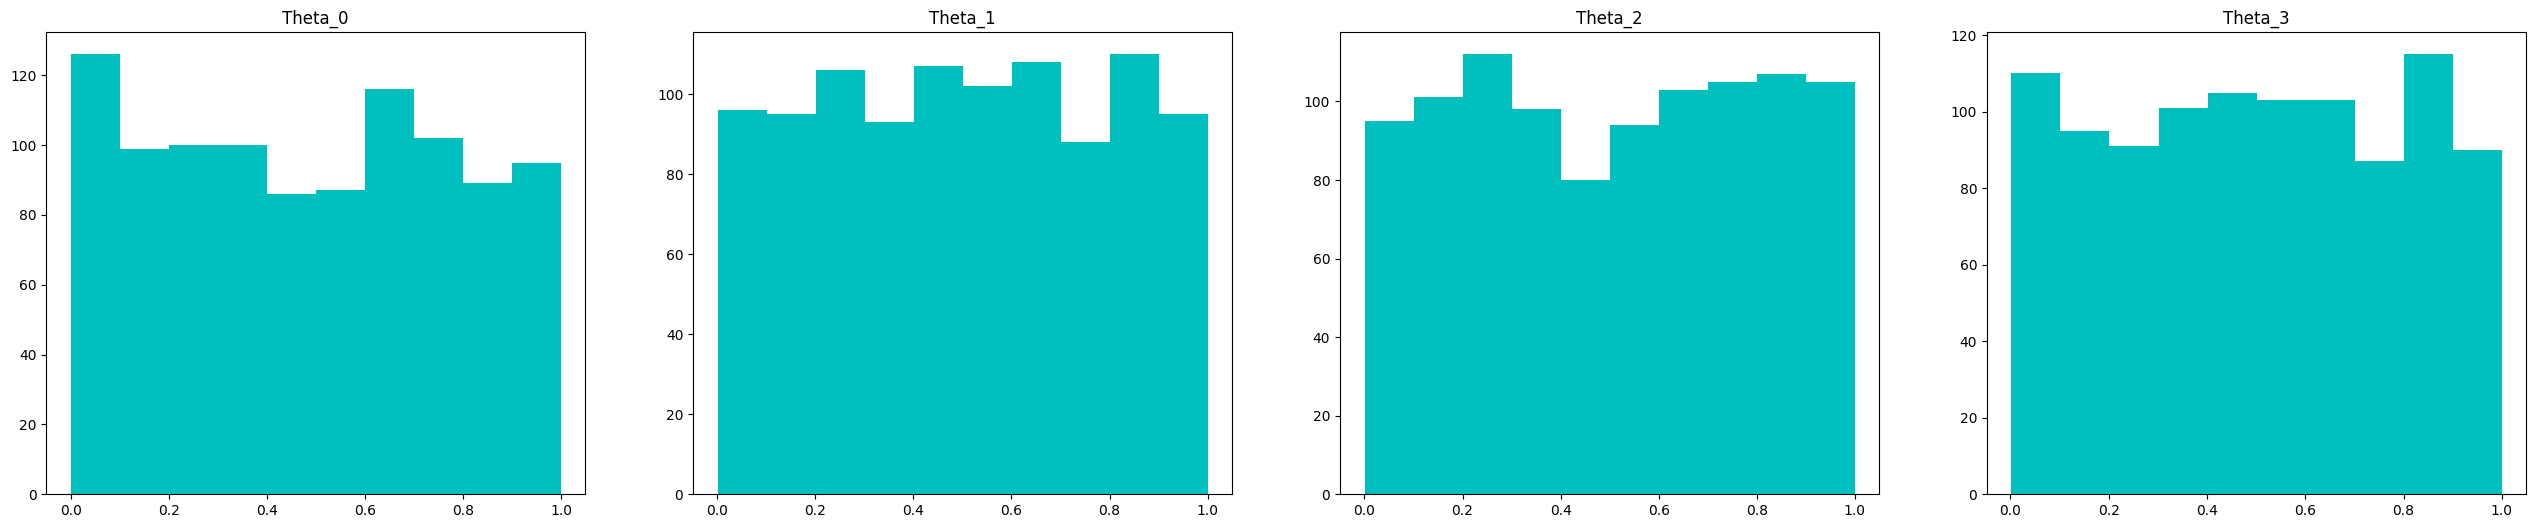

In [198]:
class MultivariatePrior:
    def __init__(self, low, high):
        self.low = np.array(low)
        self.high = np.array(high)
        self.dim = len(low)

    def logpdf(self, x):
        x = np.array(x)
        in_range = np.all((x >= self.low) & (x <= self.high))
        return 0 if in_range else -np.inf  # np.where(in_range, 0, -np.inf)

    def rvs(self, size=1):
        if isinstance(size, int):
            size = (size, self.dim)
        elif isinstance(size, tuple) and len(size) == 1:
            size = size + (self.dim,)
        samples = np.random.uniform(self.low, self.high, size=size)
        if size == 1 or (isinstance(size, tuple) and size[0] == 1):
            return samples[0]
        return samples

# Set up the prior
low = np.array([0, 0, 0, 0])
high = np.array([1, 1, 1, 1])
my_prior = MultivariatePrior(low, high)

# draw some samples and plot them
prior_samples = my_prior.rvs(size=(1000, 4))
fig, axes = plt.subplots(nrows=1, ncols=4, figsize = (8*4, 6))
for i in range(4):
    axes[i].set_title('Theta_{}'.format(i))
    axes[i].hist(prior_samples[:,i], color='c')

In [199]:
# define the likelihood
cov_likelihood = sigma**2*np.eye(data.size)

my_loglike = tda.GaussianLogLike(data, cov_likelihood)

### Set up the link factories and get the MAP point

In [200]:
# set up the link factories
my_posterior = tda.Posterior(my_prior, my_loglike, my_model)

my_posteriors = [my_posterior]

my_posterior.prior.rvs()

array([0.33028467, 0.56423182, 0.85057453, 0.20152838])

In [201]:
# get the maximum a posteriori point.
MAP = tda.get_MAP(my_posterior)
MAP

/home/paul/coding/modeling-week/modeling-week-arepo/Riemann.py:112: RuntimeWarning: invalid value encountered in sqrt
  a_R = np.sqrt( gamma *  W_R[2] / W_R[0] )
/home/paul/coding/modeling-week/modeling-week-arepo/Riemann.py:20: RuntimeWarning: invalid value encountered in sqrt
  a_K = np.sqrt(  gamma * W_K[2] / W_K[0] )
/home/paul/coding/modeling-week/modeling-week-arepo/Riemann.py:40: RuntimeWarning: invalid value encountered in sqrt
  a_K = np.sqrt( gamma_K *  W_K[2] / W_K[0] )
/home/paul/coding/modeling-week/modeling-week-arepo/Riemann.py:125: RuntimeWarning: invalid value encountered in scalar power
  astar_R = a_R * ( pstar / W_R[2] )**( (gamma - 1.0) / (2.0 * gamma) )
/home/paul/coding/modeling-week/modeling-week-arepo/Riemann.py:137: RuntimeWarning: invalid value encountered in sqrt
  PosOfCharacteristics[4] = W_R[1] + a_R * np.sqrt( gp1 / 2.0 / gamma * pstar / W_R[2] + gm1 / 2.0 / gamma )
/home/paul/coding/modeling-week/modeling-week-arepo/Riemann.py:89: RuntimeWarning: invali

array([0.97738075, 0.75078483, 0.20674792, 0.50246913])

### Set up the proposal

In [202]:
# random walk Metropolis
#rwmh_cov = np.eye(2)
#rmwh_scaling = 0.1
#rwmh_adaptive = True
#my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

# preconditioned Crank-Niconson
#pcn_scaling = 0.1
#pcn_adaptive = True
#my_proposal = tda.CrankNicolson(scaling=pcn_scaling, adaptive=pcn_adaptive)

# Adaptive Metropolis
am_cov = np.eye(true_parameters.size)
am_t0 = 100
am_sd = None
am_epsilon = 1e-6
am_adaptive = True
my_proposal = tda.AdaptiveMetropolis(C0=am_cov, t0=am_t0, sd=am_sd, epsilon=am_epsilon)

### Sample

In [203]:
import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations = 120
    burnin = 20

In [204]:
# initialise the chain
my_chain = tda.sample(my_posteriors, my_proposal, iterations=iterations, n_chains=2, initial_parameters=MAP, subchain_length=5, adaptive_error_model='state-independent', force_sequential=True)

Sampling chain 1/2
[0.97738075 0.75078483 0.20674792 0.50246913]


Running chain, α = 1.00:   0%|          | 0/120 [00:00<?, ?it/s]/home/paul/coding/modeling-week/modeling-week-arepo/Riemann.py:112: RuntimeWarning: invalid value encountered in sqrt
  a_R = np.sqrt( gamma *  W_R[2] / W_R[0] )
/home/paul/coding/modeling-week/modeling-week-arepo/Riemann.py:28: RuntimeWarning: invalid value encountered in scalar power
  return ( 2.0 * a_K / ( gamma - 1.0 ) ) * ( ( pres / W_K[2] )**exponent - 1.0 )
/home/paul/coding/modeling-week/modeling-week-arepo/Riemann.py:20: RuntimeWarning: invalid value encountered in sqrt
  a_K = np.sqrt(  gamma * W_K[2] / W_K[0] )
/home/paul/coding/modeling-week/modeling-week-arepo/Riemann.py:25: RuntimeWarning: invalid value encountered in sqrt
  return ( pres - W_K[2] ) * np.sqrt( A / ( pres + B ) )
/home/paul/coding/modeling-week/modeling-week-arepo/Riemann.py:48: RuntimeWarning: invalid value encountered in scalar power
  return ( pres / W_K[2] )**exponent / W_K[0] / a_K
/home/paul/coding/modeling-week/modeling-week-arepo/Riem

Sampling chain 2/2
[0.97738075 0.75078483 0.20674792 0.50246913]


Running chain, α = 0.06: 100%|██████████| 120/120 [00:00<00:00, 373.75it/s]


### Diagnostics

In [205]:
print(my_chain['chain_0'][0].prior)
idata = tda.to_inference_data(my_chain, level='fine', burnin=burnin)

/home/paul/temp/jupyter-kernels/dasci/lib/python3.10/site-packages/arviz/data/inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


0


In [206]:
import arviz as az

In [207]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
x0,0.749,0.245,0.444,0.977,0.154,0.126,3.0,5.0,2.48
x1,0.566,0.280,0.110,0.807,0.142,0.118,3.0,5.0,2.31
x2,0.321,0.218,0.073,0.669,0.082,0.069,10.0,4.0,2.38
x3,0.600,0.158,0.397,0.915,0.097,0.078,3.0,16.0,2.54


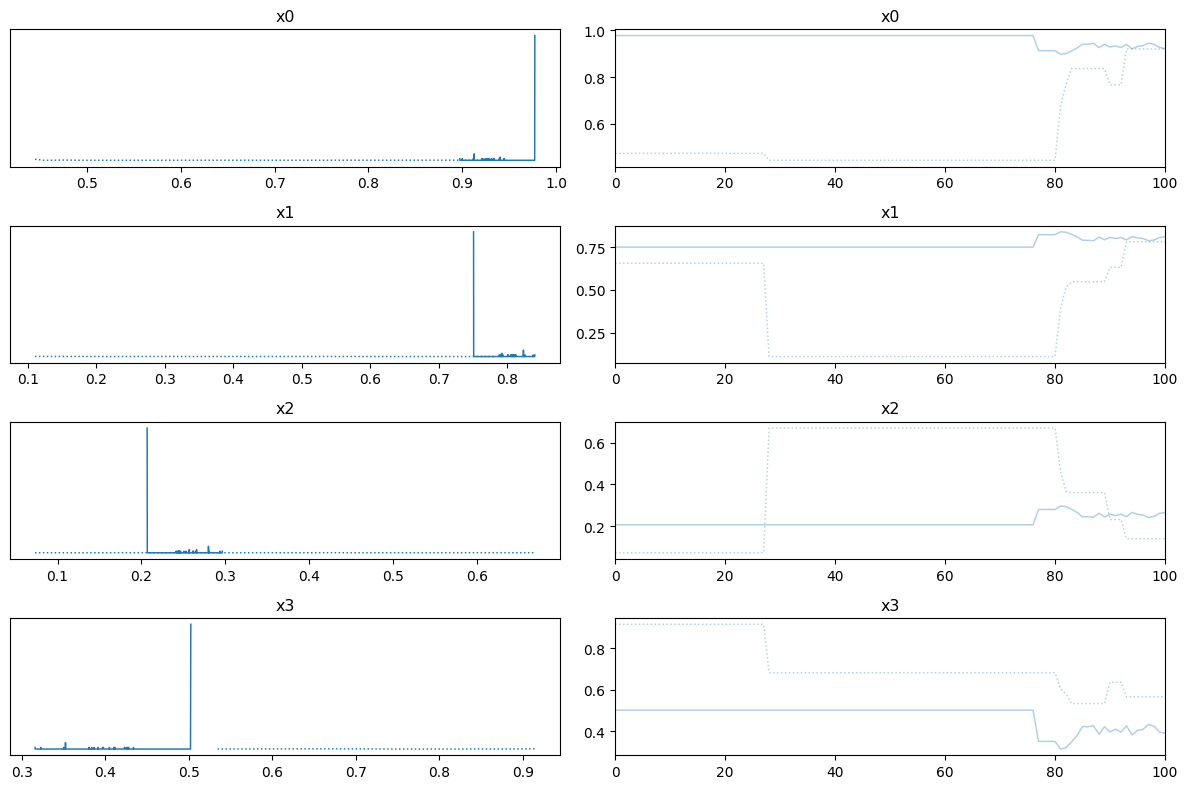

In [208]:
az.plot_trace(idata)
plt.tight_layout()
plt.show()